(interrupted-time-series-bsts)=
# Interrupted time series with a Bayesian structural time series model

This notebook shows how to use the `StateSpaceTimeSeries` model with the `InterruptedTimeSeries` experiment. The model is a Bayesian structural time series (BSTS) built on `pymc-extras.statespace`: a local level/trend component plus frequency-domain seasonality, estimated with a Kalman filter and smoother. This is the same model family that Google's CausalImpact {cite:p}`brodersen2015inferring` uses to estimate intervention effects from a single time series.

We cover three configurations:

1. Trend and seasonality only.
2. Adding control covariates as exogenous regressors.
3. Automatic covariate selection with a spike-and-slab prior, for the case where you have many candidate control series and want the model to pick the useful ones.


In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import causalpy as cp

seed = 42
rng = np.random.default_rng(seed)
sample_kwargs = {
    "draws": 400,
    "tune": 1000,
    "chains": 4,
    "target_accept": 0.95,
    "progressbar": False,
    "random_seed": seed,
}

## Simulate data

We simulate a daily series with a slow upward trend, weekly seasonality, and two control covariates that genuinely drive the outcome (`x1`, `x2`). Six more candidate covariates (`x3` ... `x8`) are pure noise; they only matter for the covariate selection section. The intervention starts on day 110 and lifts the outcome by 2 units, so we know the true causal effect.


In [2]:
n = 140
dates = pd.date_range(start="2022-01-01", periods=n, freq="D")
treatment_time = dates[110]

trend = 0.02 * np.arange(n)
seasonality = 0.8 * np.sin(2 * np.pi * np.arange(n) / 7)
X = rng.normal(size=(n, 8))
true_effect = np.where(np.arange(n) >= 110, 2.0, 0.0)

y = (
    10
    + trend
    + seasonality
    + 2.0 * X[:, 0]
    - 1.5 * X[:, 1]
    + true_effect
    + rng.normal(0, 0.3, n)
)

df = pd.DataFrame(X, columns=[f"x{i + 1}" for i in range(8)], index=dates).assign(y=y)
df.head()

,x1,x2,x3,x4,x5,x6,x7,x8,y
2022-01-01,0.304717,-1.039984,0.750451,0.940565,-1.951035,-1.302180,0.127840,-0.316243,12.304506
2022-01-02,-0.016801,-0.853044,0.879398,0.777792,0.066031,1.127241,0.467509,-0.859292,11.892361
2022-01-03,0.368751,-0.958883,0.878450,-0.049926,-0.184862,-0.680930,1.222541,-0.154529,12.770824
2022-01-04,-0.428328,-0.352134,0.532309,0.365444,0.412733,0.430821,2.141648,-0.406415,10.007903
2022-01-05,-0.512243,-0.813773,0.615979,1.128972,-0.113947,-0.840156,-0.824481,0.650593,9.873814


## Trend and seasonality only

With an intercept-only formula the model uses just its structural components. `level_order=2` gives a local linear trend (level and slope), and `seasonal_length=7` matches the weekly pattern. The counterfactual for the post-period is a genuine forecast from the Kalman filter, not an in-sample fit.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [initial_level_trend, sigma_level_trend, params_freq, sigma_freq, P0_diag]


Sampling 4 chains for 1_000 tune and 400 draw iterations (4_000 + 1_600 draws total) took 59 seconds.


Sampling: [obs]


Output()

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

Sampling: [forecast_combined]


Output()

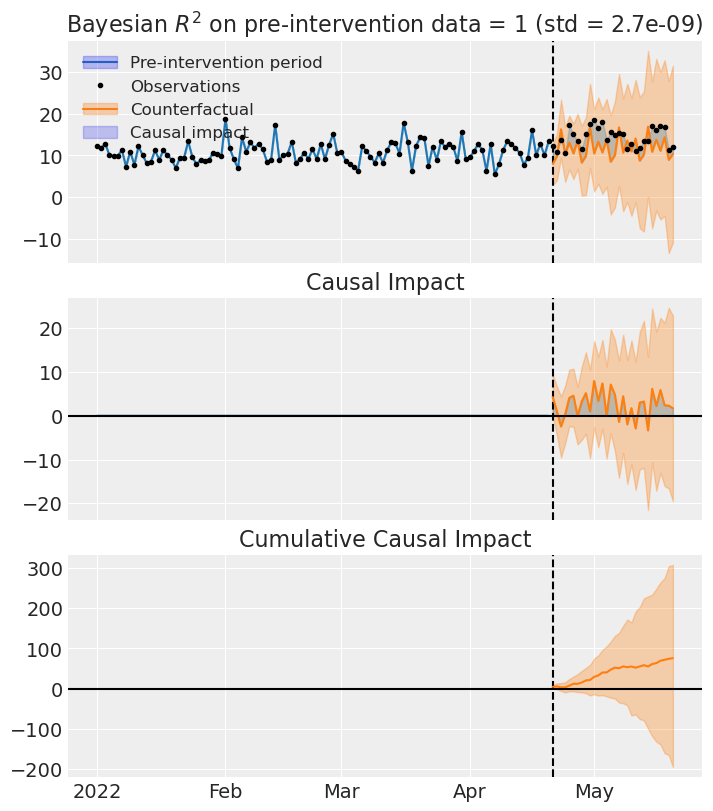

In [3]:
result_basic = cp.InterruptedTimeSeries(
    data=df[["y"]],
    treatment_time=treatment_time,
    formula="y ~ 1",
    model=cp.pymc_models.StateSpaceTimeSeries(
        level_order=2,
        seasonal_length=7,
        sample_kwargs=sample_kwargs,
    ),
)
fig, ax = result_basic.plot()

In [4]:
summary_basic = result_basic.effect_summary()
print(summary_basic.text)

During the Post-period (2022-04-21 00:00:00 to 2022-05-20 00:00:00), the response variable had an average value of approx. 14.32. By contrast, in the absence of an intervention, we would have expected an average response of 11.80. The 95% interval of this counterfactual prediction is [3.17, 20.82]. Subtracting this prediction from the observed response yields an estimate of the causal effect the intervention had on the response variable. This effect is 2.52 with a 95% interval of [-6.50, 11.16].

Summing up the individual data points during the Post-period, the response variable had an overall value of 429.74. By contrast, had the intervention not taken place, we would have expected a sum of 354.11. The 95% interval of this prediction is [95.01, 624.69]. The cumulative effect is 75.63 with a 95% HDI [-194.96, 334.73].

The posterior probability of an increase is 0.749. For the cumulative effect, The posterior probability of an increase is 0.749. Relative to the counterfactual, the effe

Without the covariates the model does not identify the effect. The point estimate is in the right region, with a true effect of 2.0, but the 95% interval is several times wider than the effect itself and comfortably includes zero, and the posterior probability of an increase lands around 0.75, nowhere near conclusive. Two things drive this. The variation that `x1` and `x2` explain is left in the noise, and a local linear trend (`level_order=2`) forecast widens quickly over a 30 day horizon.

Ignore the `Bayesian R² on pre-intervention data = 1` in the plot title. In-sample predictions from a state-space model come from the Kalman smoother, which conditions on the observed outcome, so the smoothed states interpolate the pre-period almost exactly and the R² is pinned at 1 whatever the fit. It is not a goodness-of-fit measure here, and it is not comparable with the R² of a model that predicts from covariates alone. Judge the model on the post-period counterfactual instead.

## Adding control covariates

Covariates enter the state-space model through a static regression component, so the counterfactual uses the post-period covariate values when forecasting. Use a `0 +` formula: the state-space level already absorbs the intercept, and the model drops a patsy `Intercept` column (with a warning) if you leave it in.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [initial_level_trend, sigma_level_trend, params_freq, sigma_freq, beta_exog, P0_diag]


Sampling 4 chains for 1_000 tune and 400 draw iterations (4_000 + 1_600 draws total) took 72 seconds.


There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


...

Output()

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

Sampling: [forecast_combined]


Output()

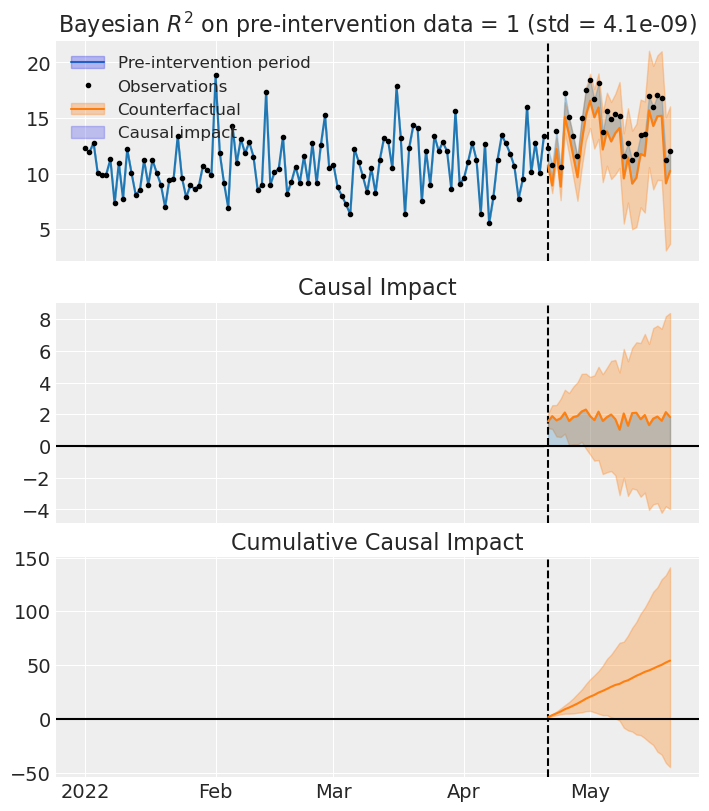

In [5]:
result_covariates = cp.InterruptedTimeSeries(
    data=df,
    treatment_time=treatment_time,
    formula="y ~ 0 + x1 + x2",
    model=cp.pymc_models.StateSpaceTimeSeries(
        level_order=2,
        seasonal_length=7,
        sample_kwargs=sample_kwargs,
    ),
)
fig, ax = result_covariates.plot()

In [6]:
az.summary(
    result_covariates.idata,
    var_names=["beta_exog"],
    kind="stats",
    ci_kind="hdi",
    ci_prob=0.94,
)

,mean,sd,hdi94_lb,hdi94_ub
beta_exog[x1],2,1.5,-0.91,4.7
beta_exog[x2],-1.5,1.4,-4.4,1.4


In [7]:
summary_covariates = result_covariates.effect_summary()
print(summary_covariates.text)

During the Post-period (2022-04-21 00:00:00 to 2022-05-20 00:00:00), the response variable had an average value of approx. 14.32. By contrast, in the absence of an intervention, we would have expected an average response of 12.52. The 95% interval of this counterfactual prediction is [9.44, 15.90]. Subtracting this prediction from the observed response yields an estimate of the causal effect the intervention had on the response variable. This effect is 1.81 with a 95% interval of [-1.58, 4.88].

Summing up the individual data points during the Post-period, the response variable had an overall value of 429.74. By contrast, had the intervention not taken place, we would have expected a sum of 375.55. The 95% interval of this prediction is [283.19, 477.04]. The cumulative effect is 54.19 with a 95% HDI [-47.30, 146.55].

The posterior probability of an increase is 0.869. For the cumulative effect, The posterior probability of an increase is 0.869. Relative to the counterfactual, the effec

The posterior means for the coefficients sit on the true values (2.0 and -1.5), but each one is individually uncertain: the 94% HDIs still span zero, because the state-space level and the regressors compete to explain the same variation. What the counterfactual uses is their joint contribution, and that is enough to tighten the effect interval and raise the posterior probability of an increase. The effect is still not credibly different from zero at the 95% level with 30 post-period days at this noise level.

PyMC reports 2 divergences for this fit. At this count they are worth noting rather than acting on; raise `target_accept` above the 0.95 used here if you see many more.

## Automatic covariate selection

When you have many candidate control series, a spike-and-slab prior on the regression coefficients lets the model decide which ones matter, mirroring CausalImpact's approach. Pass `vs_prior_type="spike_and_slab"` and give the model all candidates.

Read the posterior inclusion probabilities as a relative ranking of the candidates rather than as calibrated probabilities. Under this prior the `beta_exog` point estimates shrink toward zero (the state-space initial covariance lets the regression states drift from the parameter), but the counterfactual forecast comes from the smoothed states and is not affected.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [initial_level_trend, sigma_level_trend, params_freq, sigma_freq, pi_beta_exog, beta_exog_raw, gamma_beta_exog_u, P0_diag]


Sampling 4 chains for 1_000 tune and 400 draw iterations (4_000 + 1_600 draws total) took 368 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


...

Output()

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

Sampling: [forecast_combined]


Output()

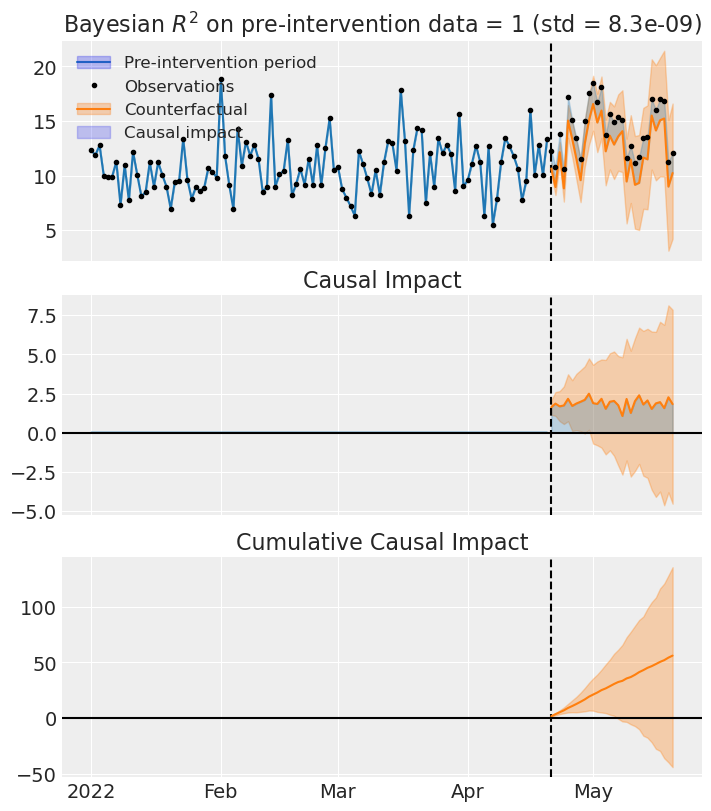

In [8]:
result_selection = cp.InterruptedTimeSeries(
    data=df,
    treatment_time=treatment_time,
    formula="y ~ 0 + " + " + ".join(f"x{i + 1}" for i in range(8)),
    model=cp.pymc_models.StateSpaceTimeSeries(
        level_order=2,
        seasonal_length=7,
        sample_kwargs=sample_kwargs,
        vs_prior_type="spike_and_slab",
    ),
)
fig, ax = result_selection.plot()

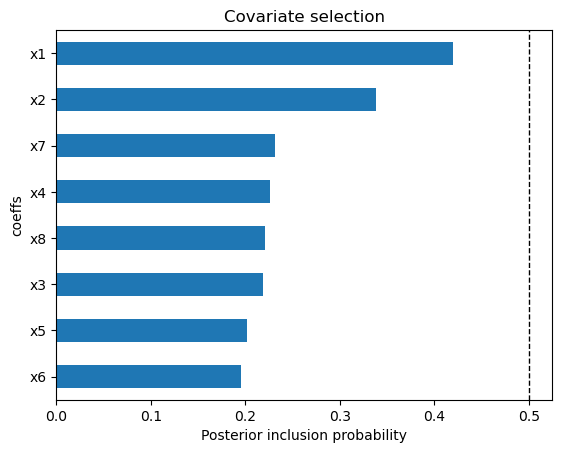

In [9]:
inclusion = result_selection.model.get_inclusion_probabilities()

fig, ax = plt.subplots()
inclusion["prob"].sort_values().plot.barh(ax=ax)
ax.axvline(0.5, color="k", linestyle="--", linewidth=1)
ax.set(xlabel="Posterior inclusion probability", title="Covariate selection")
plt.show()

The two real predictors, `x1` and `x2`, take the top two places, but the margin over the six noise covariates is modest and no candidate clears the dashed 0.5 line. Read the ordering rather than the level: as noted above, the inclusion probabilities under this prior are not calibrated, so 0.5 is a conventional reference mark and not a threshold this model is tuned against.

PyMC reports an rhat above 1.01 for this model. Spike-and-slab posteriors are multimodal by construction, so chains can disagree about which covariates are in the model. Note that this affects the inclusion probabilities too, since they are the average of the selection indicators over those same chains, so treat the ranking below as provisional rather than as a safe fallback. Run more chains and inspect them separately before relying on the ordering, and raise `tune` and `draws` if you need tighter per-coefficient estimates.

## Notes

- The model needs a `pandas.DatetimeIndex` and a single treated unit.
- Missing values in the outcome are handled natively by the Kalman filter; covariates must be complete.
- Override priors per parameter with the `priors` argument, e.g. `priors={"sigma_freq": Prior("HalfNormal", sigma=1)}`.

## References

:::{bibliography}
:filter: docname in docnames
:::
